## Setup

In [1]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.6 MB/s eta 0:00:00


In [2]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# IMPORT TORCH
# ============================================================
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# ============================================================
# ALL PATHS
# ============================================================

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"

MODEL_NAME      = "m5a"
CHECKPOINT_PATH = f'/content/drive/MyDrive/210/{MODEL_NAME}.pth'

print(f"TAR_DIR:    {TAR_DIR}")
print(f"LABELS_CSV: {LABELS_CSV}")
print(f"GEO_PARQUET: {GEO_PARQUET}")
print(f"CHECKPOINT: {CHECKPOINT_PATH}")

TAR_DIR:    /content/gaze_wds_balanced
LABELS_CSV: /content/drive/MyDrive/210/gaze_labels.csv
GEO_PARQUET: /content/drive/MyDrive/210/geo_features_v1.parquet
CHECKPOINT: /content/drive/MyDrive/210/m5a.pth


## Load data to disk

In [6]:
# ============================================================
# LOAD DATA
# ============================================================
# ============================================================
# COPY TARS TO LOCAL COLAB DISK (~10 min)
# Reading from Drive during training is slow, so we copy first.
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [10]:
# ============================================================
# VERIFY FILES
# ============================================================

all_tars_training = sorted(glob.glob("/content/gaze_wds_balanced/**/*.tar", recursive=True))
print(f"Training tars: {len(all_tars_training)}")

# And how many were in the original extraction
print(f"Extraction ran on: 107 tars (320,000 samples)")

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Labels CSV: {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Training tars: 107
Extraction ran on: 107 tars (320,000 samples)
Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True


In [11]:
# ============================================================
# LOAD LABELS
# ============================================================
# ============================================================
# LOAD LABELS → label_lookup dict
# Maps sample key (e.g. "00003_000000") to label string
#
# Then filter to 4 classes (drop Straight)
# ============================================================

# ---- Step 1: Build full 4-class lookup ----
df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

print(f"Label lookup: {len(label_lookup)} entries")

# ---- Step 2: Filter to 4 classes (drop Straight) ----
# m5 hypothesis: Straight is the #1 source of errors and its
# decision boundary is genuinely ambiguous. Removing it
# should boost accuracy on the remaining classes AND
# reduce overfitting since the model no longer needs to
# memorize to distinguish "slightly left" from "straight."

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}

label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}
print(f"\nFiltered (no Straight): {len(label_lookup_4)} entries")
print(f"Dropped: {len(label_lookup) - len(label_lookup_4)} Straight samples")

Loaded 849131 labeled frames
Label lookup: 849131 entries

Filtered (no Straight): 602467 entries
Dropped: 246664 Straight samples


In [12]:
# ============================================================
# LOAD GEO FEATURES
# ============================================================
# ============================================================
# LOAD GEO FEATURES → geo_lookup dict
# Maps sample key to numpy array of 7 features.
# Precomputed locally with MediaPipe, uploaded to Drive.
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# After geo_lookup is built
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
missing = len(label_lookup_4) - matched
print(f"\nGeo coverage: {matched}/{len(label_lookup_4)} samples have geo features ({100*matched/len(label_lookup_4):.1f}%)")
if missing > 0:
    print(f"  WARNING: {missing} samples will use GEO_DEFAULT fallback")
    # Show a few missing keys for debugging
    missing_keys = [k for k in label_lookup_4 if k not in geo_lookup][:5]
    print(f"  Example missing keys: {missing_keys}")
    # And show a few geo keys for comparison
    geo_sample = list(geo_lookup.keys())[:5]
    print(f"  Example geo keys:     {geo_sample}")

# Neutral default for samples missing from geo_lookup
# (roughly dataset means)
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries

Geo coverage: 192519/602467 samples have geo features (32.0%)
  Example missing keys: ['00010_000001', '00010_000002', '00010_000005', '00010_000006', '00010_000008']
  Example geo keys:     ['00003_000000', '00003_000001', '00003_000002', '00003_000003', '00003_000004']
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


In [13]:
# ============================================================
# SANITY CHECK
# ============================================================
all_tars = train_tar_urls + val_tar_urls + test_tar_urls

tar_keys = set()
ds = wds.WebDataset(all_tars, shardshuffle=False).decode("pil")
for sample in ds:
    tar_keys.add(sample["__key__"])

in_tar_and_labeled = tar_keys & set(label_lookup_4.keys())
in_tar_labeled_and_geo = in_tar_and_labeled & set(geo_lookup.keys())

print(f"Total tar samples:                {len(tar_keys)}")
print(f"Non-Straight and in tars:         {len(in_tar_and_labeled)}")
print(f"Non-Straight, in tars, with geo:  {len(in_tar_labeled_and_geo)}")
print(f"Real geo coverage:                {100*len(in_tar_labeled_and_geo)/len(in_tar_and_labeled):.1f}%")

Total tar samples:                320000
Non-Straight and in tars:         197573
Non-Straight, in tars, with geo:  192519
Real geo coverage:                97.4%


## Augment Data

In [14]:
# ============================================================
# IMAGE TRANSFORMATIONS
# ============================================================

# ============================================================
# IMAGE TRANSFORMS
#
# Training: augmentation (color jitter, grayscale, blur)
# Val/Test: clean (just resize and normalize)
#
# Eye images: resize to 48x48 (from 60x36 raw)
# Face images: already 112x112, no resize needed
# Normalization: mean=0.5, std=0.5 for all channels
# ============================================================

# ---- Training transforms (with augmentation) ----
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ---- Val/Test transforms (no augmentation) ----
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


## Data Pipeline

In [15]:
# ============================================================
# MAKE DATASET FUNCTION
# ============================================================
# ============================================================
# make_dataset_4class: WebDataset pipeline with geo features
#
# Uses label_map_4 and label_lookup_4 so Straight samples
# return None and get filtered out.
# ============================================================

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        # ---- Skip Straight samples entirely ----
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


## Define Model

In [16]:
# ============================================================
# DEFINE MODEL
# ============================================================
# ============================================================
# GazeNetM5 — Model Definition
#
# Same CNN streams as v16A GazeNet, plus a small MLP branch
# that processes our 7 geometric features.
#
# Architecture:
#   left_eye image  -> Eye CNN (shared weights) -> 4608 dims -+
#   right_eye image -> Eye CNN (shared weights) -> 4608 dims -+
#   face image      -> Face CNN                 -> 2304 dims -+
#   7 geo features  -> MLP (7->64->64)          ->   64 dims -+
#                                                             +-> FC -> 4 classes
#                                                    total: 11584
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        # Input: (batch, 3, 48, 48) -> Output: (batch, 128, 6, 6)
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 24x24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 12x12

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 6x6
        )
        # Flattened: 128 * 6 * 6 = 4608 per eye

        # ---- Face CNN ----
        # Input: (batch, 3, 112, 112) -> Output: (batch, 256, 3, 3)
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),  # 112->56
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->28

            nn.Conv2d(32, 64, kernel_size=5, padding=2),            # ->28
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->14

            nn.Conv2d(64, 128, kernel_size=3, padding=1),           # ->14
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->7

            nn.Conv2d(128, 256, kernel_size=3, padding=1),          # ->7
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->3
        )
        # Flattened: 256 * 3 * 3 = 2304

        # ---- Geometric feature branch ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),   # 7 -> 64
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),             # 64 -> 64
            nn.ReLU(),
        )

        # ---- FC classifier ----
        # Concatenated input: 4608 + 4608 + 2304 + 64 = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),  # 11584 -> 512
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),                     # 512 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),              # 256 -> 4
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)    # -> 4608
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)  # -> 4608
        face_feat  = self.face_cnn(face).view(face.size(0), -1)           # -> 2304
        geo_feat   = self.geo_mlp(geo_features)                            # -> 64

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)  # -> 11584
        return self.fc(combined)

print("GazeNetM5 defined")
print(f"  Default num_classes: 4")
_test = GazeNetM5(num_classes=4)
print(f"  Parameters: {sum(p.numel() for p in _test.parameters()):,}")
print(f"  FC output layer shape: {_test.fc[-1].weight.shape}")
del _test

GazeNetM5 defined
  Default num_classes: 4
  Parameters: 6,586,820
  FC output layer shape: torch.Size([4, 256])


In [17]:
# ============================================================
# MODEL SETUP
# ============================================================
# ============================================================
# m5 setup — loaders, model, optimizer, scheduler
# ============================================================

# ---- Loaders using 4-class dataset ----
train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

# ---- Model with 4 classes ----
model = GazeNetM5(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Model: {MODEL_NAME}")
print(f"Using device: {device}")
print(f"Classes: {list(label_map_4.keys())}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"FC output shape: {model.fc[-1].weight.shape}  <-- should be [4, 256]")

Model: m5a
Using device: cuda
Classes: ['Up', 'Down', 'Left', 'Right']
Parameters: 6,586,820
FC output shape: torch.Size([4, 256])  <-- should be [4, 256]


In [18]:
# ============================================================
# CHECK CLASS BALANCE
# ============================================================
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    counts = {i: 0 for i in range(4)}
    total = 0
    for batch in loader:
        for lbl in batch['label'].tolist():
            counts[lbl] += 1
            total += 1
    print(f"{name}: {total} samples, distribution: {counts}")

train: 139521 samples, distribution: {0: 4247, 1: 51514, 2: 42872, 3: 40888}
val: 28282 samples, distribution: {0: 912, 1: 11055, 2: 8644, 3: 7671}
test: 29770 samples, distribution: {0: 867, 1: 11016, 2: 9236, 3: 8651}


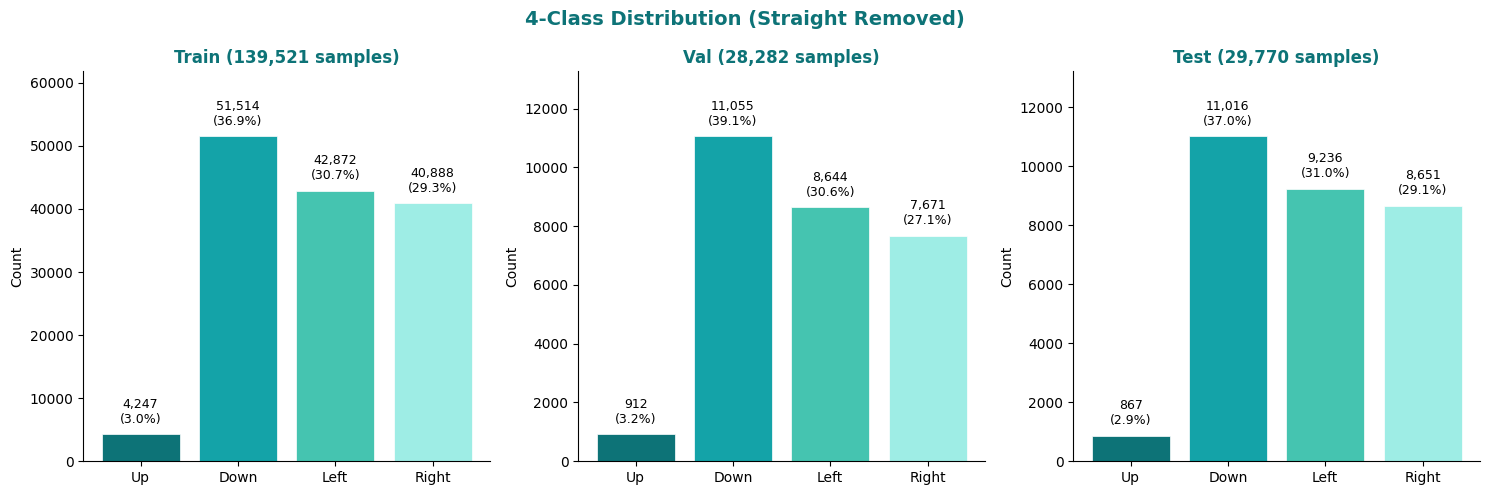

In [21]:
import matplotlib.pyplot as plt
import numpy as np

label_names = ['Up', 'Down', 'Left', 'Right']
train_counts = [4247, 51514, 42872, 40888]
val_counts = [912, 11055, 8644, 7671]
test_counts = [867, 11016, 9236, 8651]

colors = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, counts, split in zip(axes, [train_counts, val_counts, test_counts], ['Train', 'Val', 'Test']):
    total = sum(counts)
    bars = ax.bar(label_names, counts, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{split} ({total:,} samples)', fontsize=12, fontweight='bold', color='#0D7377')
    ax.set_ylabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{c:,}\n({100*c/total:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(counts) * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('4-Class Distribution (Straight Removed)', fontsize=14, fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

## Test Pipeline

In [20]:
# ============================================================
# TEST PIPELINE
# ============================================================
# ============================================================
# SMOKE TEST: Run one batch through the full pipeline
# Confirms: tar loading -> image transforms -> geo lookup -> model forward pass
# ============================================================

test_tar = [train_tar_urls[0]]
print(f"Testing with: {test_tar[0]}")

test_ds = make_dataset_4class(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))

print(f"\nBatch contents:")
print(f"  left_eye:     {batch['left_eye'].shape}")
print(f"  right_eye:    {batch['right_eye'].shape}")
print(f"  face:         {batch['face'].shape}")
print(f"  geo_features: {batch['geo_features'].shape}")
print(f"  label:        {batch['label'].shape}")
print(f"  label values: {batch['label'].tolist()}  (should be 0-3, no 4s)")

model.eval()
with torch.no_grad():
    outputs = model(
        batch['left_eye'].to(device),
        batch['right_eye'].to(device),
        batch['face'].to(device),
        batch['geo_features'].to(device),
    )

print(f"\nModel output: {outputs.shape}  <-- should be [4, 4]")
print(f"Pipeline works end-to-end!")

Testing with: /content/gaze_wds_balanced/train/gaze-train-000000.tar

Batch contents:
  left_eye:     torch.Size([4, 3, 48, 48])
  right_eye:    torch.Size([4, 3, 48, 48])
  face:         torch.Size([4, 3, 112, 112])
  geo_features: torch.Size([4, 7])
  label:        torch.Size([4])
  label values: [1, 1, 1, 1]  (should be 0-3, no 4s)

Model output: torch.Size([4, 4])  <-- should be [4, 4]
Pipeline works end-to-end!


# Train Model

In [22]:
# ============================================================
# TRAIN MODEL
# ============================================================
# ============================================================
# m5 TRAINING LOOP — Two-phase with CNN freezing
#
# Phase 1: All parameters train normally
# Phase 2: CNN frozen, only geo_mlp + fc train
#
# Transition happens when val loss hasn't improved
# in FREEZE_PATIENCE epochs.
# ============================================================

# ---- Hyperparameters ----
FREEZE_PATIENCE = 3

num_epochs = 20
best_val_loss = float('inf')

# Early stopping (kills training entirely)
patience = 6
patience_counter = 0

# CNN freeze tracking (transitions from phase 1 → phase 2)
freeze_counter = 0
cnn_frozen = False

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    phase_str = "PHASE 2 (CNN frozen)" if cnn_frozen else "PHASE 1 (all training)"
    print(f"Epoch {epoch+1}/{num_epochs} — {phase_str}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # ============================================
    # CHECKPOINT: Save best model
    # ============================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
        freeze_counter = 0   # reset freeze counter too
    else:
        patience_counter += 1
        freeze_counter += 1

        # ==============================================
        # CNN FREEZE CHECK
        # If val loss hasn't improved in FREEZE_PATIENCE
        # epochs and we haven't frozen yet, freeze now.
        # ==============================================
        if not cnn_frozen and freeze_counter >= FREEZE_PATIENCE:
            print(f"\n  *** FREEZING CNN WEIGHTS ***")
            print(f"  Val loss hasn't improved in {FREEZE_PATIENCE} epochs")
            print(f"  Only geo_mlp and fc will train from here")

            # Freeze eye CNN and face CNN
            for param in model.eye_cnn.parameters():
                param.requires_grad = False
            for param in model.face_cnn.parameters():
                param.requires_grad = False

            cnn_frozen = True

            # Rebuild optimizer with only unfrozen params
            optimizer = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=1e-4, weight_decay=5e-4
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=3, factor=0.5
            )

            # Reset early stopping to give phase 2 a fair chance
            patience_counter = 0
            print(f"  Early stopping counter reset for phase 2\n")

        else:
            print(f"  No improvement ({patience_counter}/{patience})")

    # ============================================
    # EARLY STOPPING
    # ============================================
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"CNN was frozen: {cnn_frozen}")


Epoch 1/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.6920 - ETA: 13.6 min
  Batch 2000/~7000 - Loss: 0.6679 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.6097 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.4428 - ETA: 6.3 min

  Time: 9.4 min
  Train Loss: 0.6495 | Train Acc: 85.54%
  Val Loss:   0.5404 | Val Acc:   90.65%
  Gap: -5.12%
  Saved best model (val_loss=0.5404)

Epoch 2/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.4460 - ETA: 13.6 min
  Batch 2000/~7000 - Loss: 0.5496 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.5292 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.4275 - ETA: 6.3 min

  Time: 9.3 min
  Train Loss: 0.5045 | Train Acc: 93.37%
  Val Loss:   0.5039 | Val Acc:   92.45%
  Gap: 0.91%
  Saved best model (val_loss=0.5039)

Epoch 3/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.4313 - ETA: 13.6 min
  Batch 2000/~7000 - Loss: 0.4030 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.4683 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.6305 - ETA: 6.3 

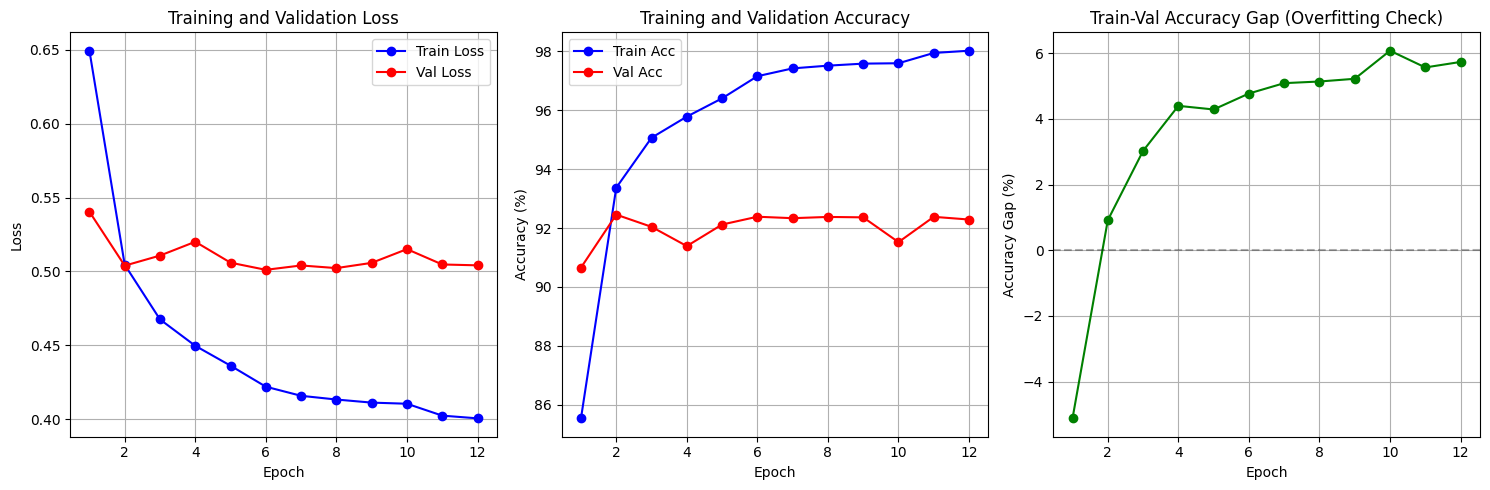


Training Summary
Total epochs completed: 12
Best validation loss: 0.5011 (Epoch 6)
Best validation accuracy: 92.45% (Epoch 2)
Final train accuracy: 98.02%
Final val accuracy: 92.29%
Final train-val gap: 5.73%


In [23]:
# ============================================================
# LOSS CURVES
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

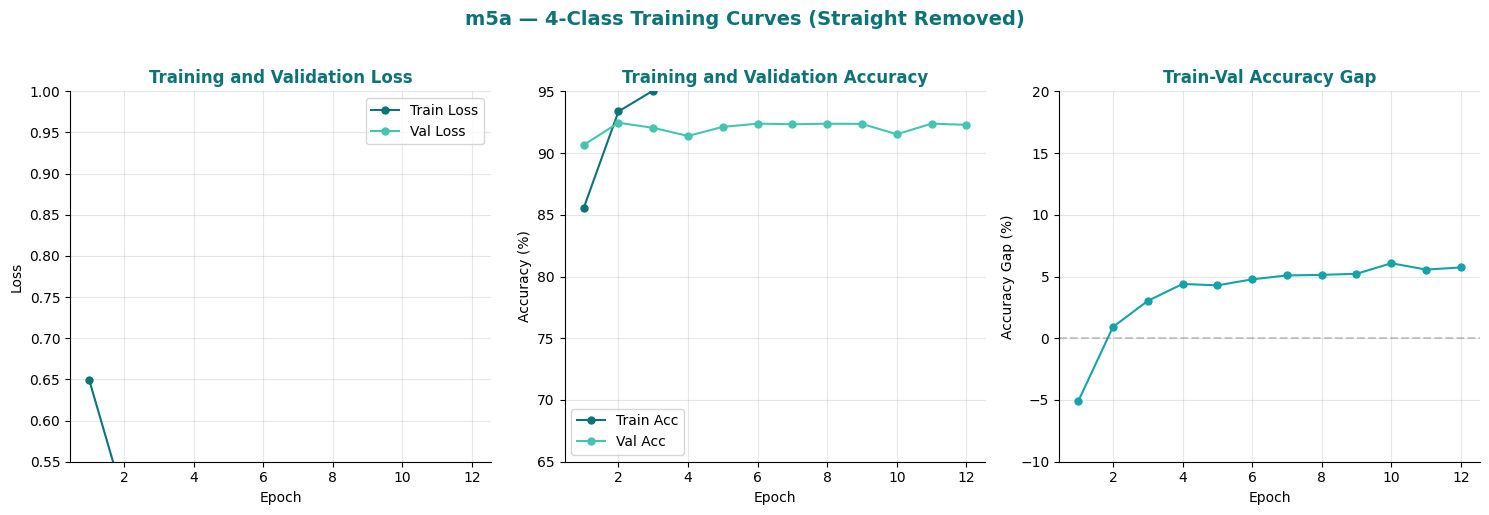


Training Summary
Total epochs completed: 12
Best validation loss: 0.5011 (Epoch 6)
Best validation accuracy: 92.45% (Epoch 2)
Final train accuracy: 98.02%
Final val accuracy: 92.29%
Final train-val gap: 5.73%


In [24]:
# ============================================================
# LOSS CURVES — Teal theme, y-axes aligned for comparison
# ============================================================

teal_dark = '#0D7377'
teal_mid = '#14A3A8'
teal_light = '#45C4B0'
teal_pale = '#9EEDE5'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.set_ylim(0.55, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.set_ylim(65, 95)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.set_ylim(-10, 20)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Straight Removed)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

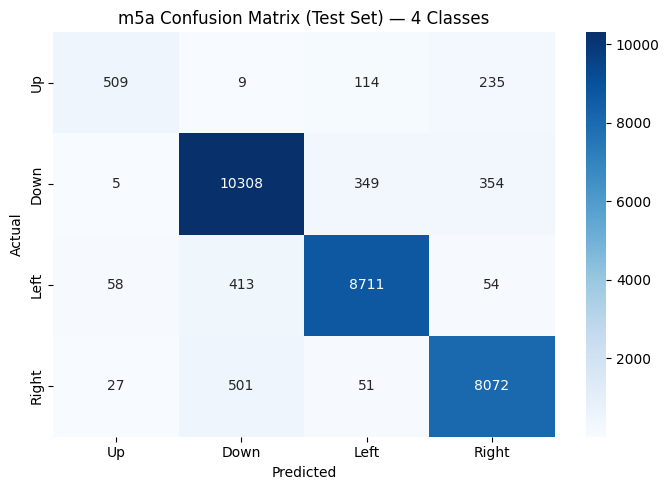


m5a Test Set Performance
              precision    recall  f1-score   support

          Up       0.85      0.59      0.69       867
        Down       0.92      0.94      0.93     11016
        Left       0.94      0.94      0.94      9236
       Right       0.93      0.93      0.93      8651

    accuracy                           0.93     29770
   macro avg       0.91      0.85      0.87     29770
weighted avg       0.93      0.93      0.93     29770



In [25]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX — 4 classes
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- 4-class labels ----
label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

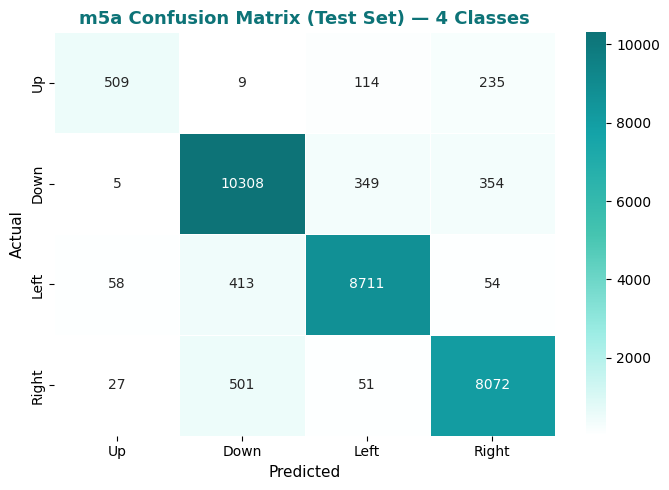


m5a Test Set Performance
              precision    recall  f1-score   support

          Up       0.85      0.59      0.69       867
        Down       0.92      0.94      0.93     11016
        Left       0.94      0.94      0.94      9236
       Right       0.93      0.93      0.93      8651

    accuracy                           0.93     29770
   macro avg       0.91      0.85      0.87     29770
weighted avg       0.93      0.93      0.93     29770



In [29]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX — 4 classes TEAL!
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- 4-class labels ----
label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

# ---- Teal colormap ----
from matplotlib.colors import LinearSegmentedColormap
teal_cmap = LinearSegmentedColormap.from_list('teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

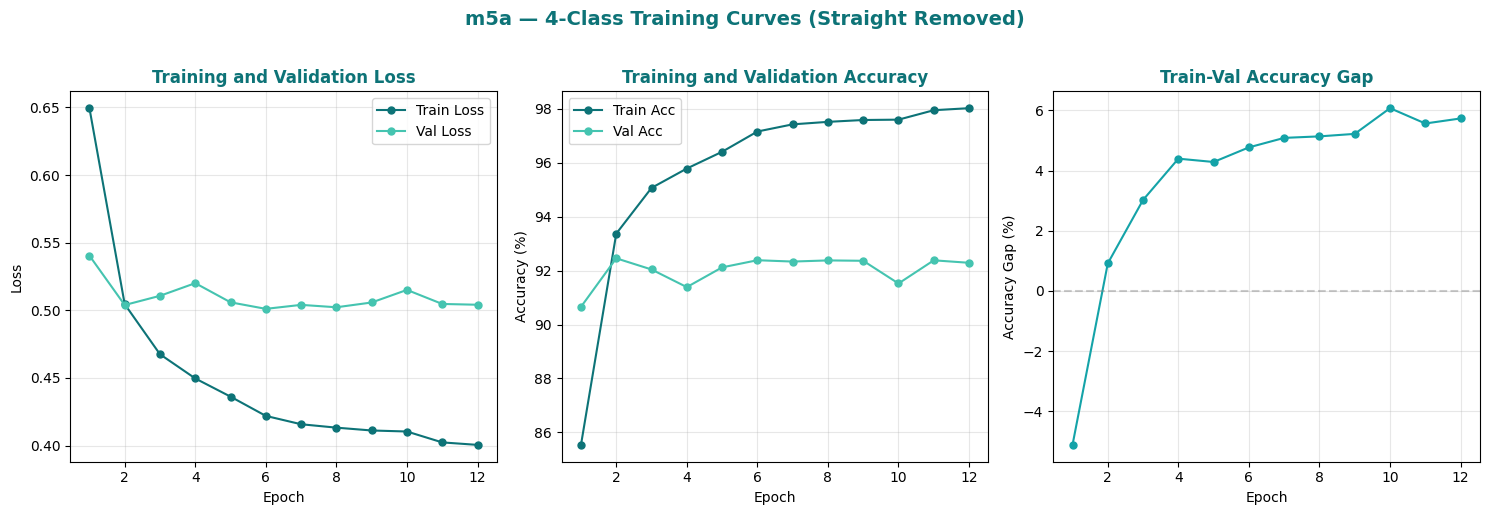


Training Summary
Total epochs completed: 12
Best validation loss: 0.5011 (Epoch 6)
Best validation accuracy: 92.45% (Epoch 2)
Final train accuracy: 98.02%
Final val accuracy: 92.29%
Final train-val gap: 5.73%


In [27]:
# ============================================================
# LOSS CURVES — Teal theme
# ============================================================

teal_dark = '#0D7377'
teal_mid = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Straight Removed)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

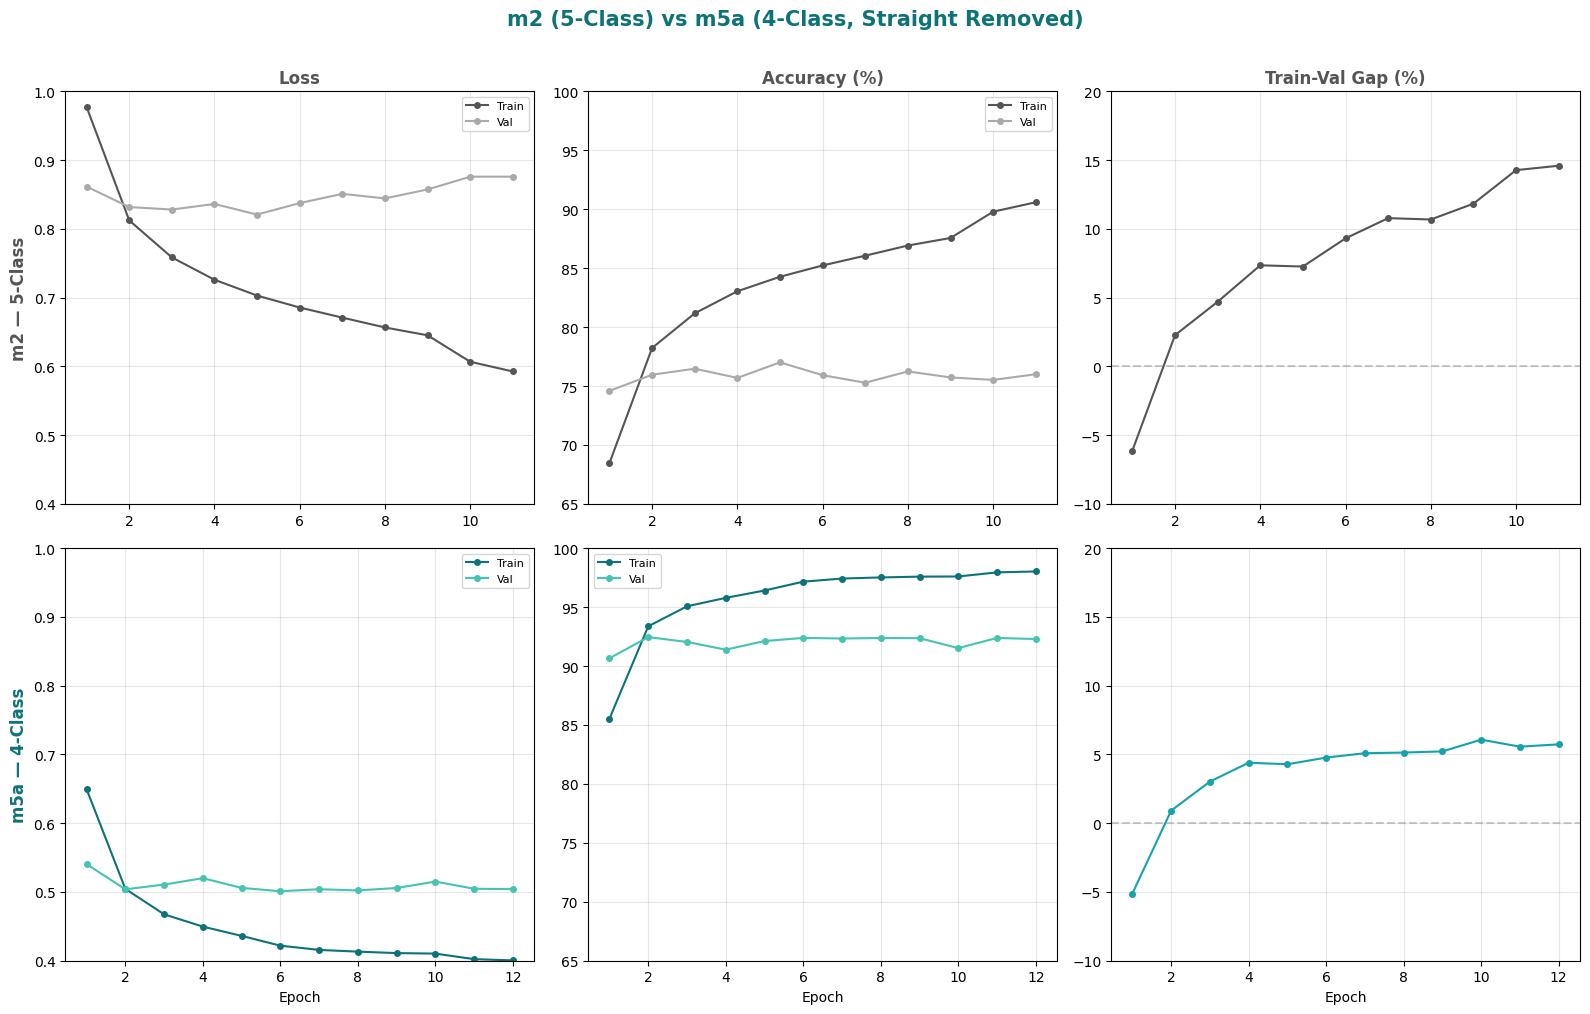

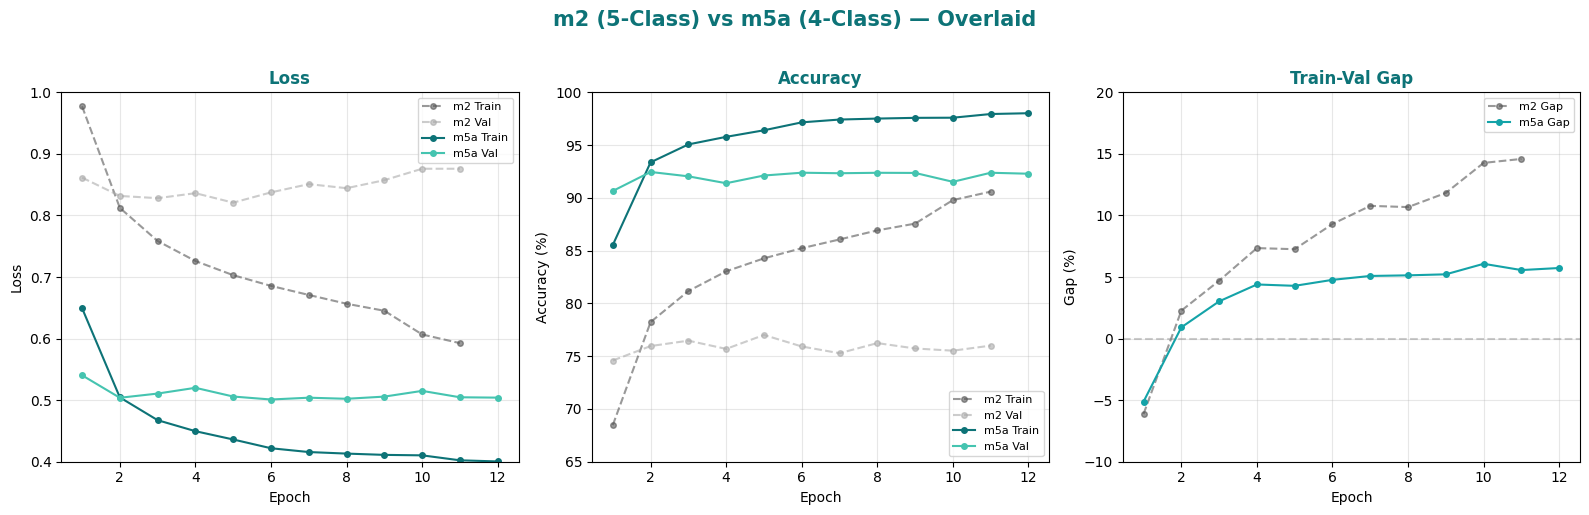

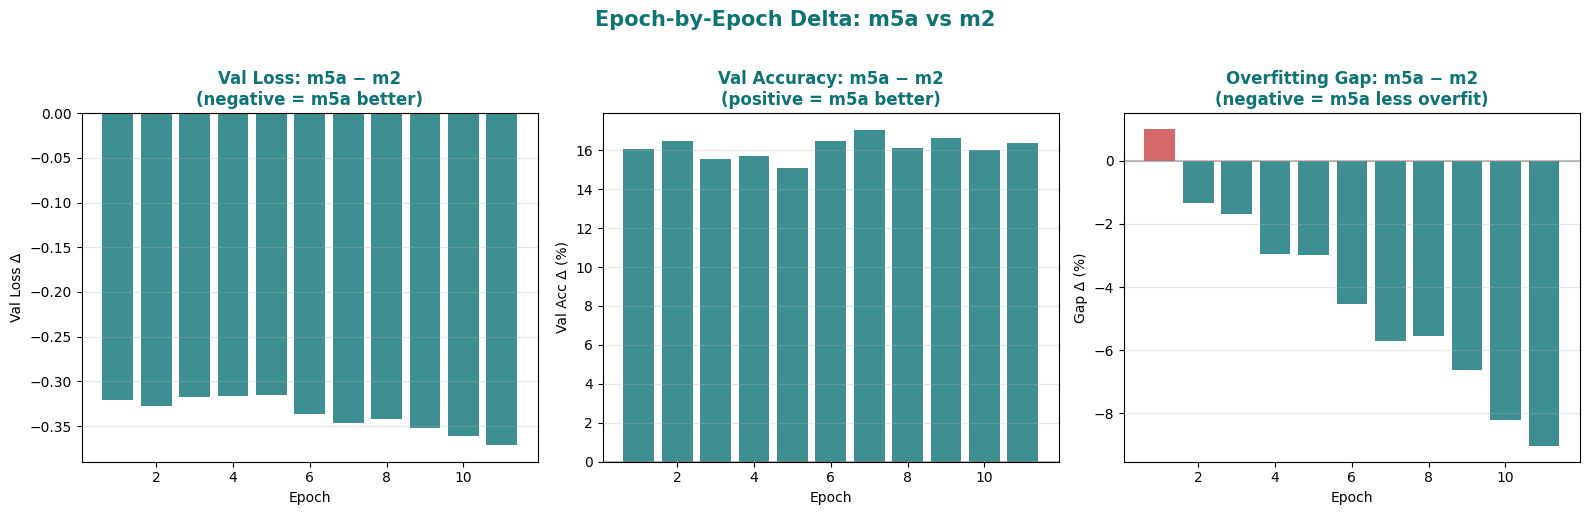

Best Checkpoint Comparison
                       m2 (5-class)  m5a (4-class)
-------------------------------------------------------
Best val loss                0.8208         0.5011
Best val acc                 77.01%         92.45%
Gap at best epoch             7.26%          0.91%
Epochs to early stop             11             12


In [28]:
# ============================================================
# m2 data (hardcoded from training log)
# ============================================================
train_losses_m2 = [0.9773, 0.8123, 0.7585, 0.7260, 0.7030, 0.6856, 0.6709, 0.6566, 0.6452, 0.6067, 0.5926]
val_losses_m2   = [0.8615, 0.8317, 0.8281, 0.8362, 0.8208, 0.8375, 0.8509, 0.8443, 0.8573, 0.8759, 0.8759]
train_acc_m2    = [68.47, 78.23, 81.17, 83.04, 84.27, 85.23, 86.06, 86.92, 87.56, 89.79, 90.59]
val_acc_m2      = [74.59, 75.96, 76.47, 75.69, 77.01, 75.92, 75.28, 76.24, 75.73, 75.52, 76.00]
gap_m2          = [t - v for t, v in zip(train_acc_m2, val_acc_m2)]

# m5a data (from active runtime)
gap_m5a = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]

# Colors
teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'
teal_pale  = '#9EEDE5'
gray_dark  = '#555555'
gray_light = '#AAAAAA'


# ============================================================
# OPTION 1: Side-by-side panels, shared axes
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# -- Top row: m2 (5-class) --
ax = axes[0, 0]
ax.plot(range(1, len(train_losses_m2)+1), train_losses_m2, '-o', color=gray_dark, label='Train', markersize=4)
ax.plot(range(1, len(val_losses_m2)+1), val_losses_m2, '-o', color=gray_light, label='Val', markersize=4)
ax.set_ylim(0.4, 1.0); ax.set_title('Loss', fontweight='bold', color=gray_dark)
ax.set_ylabel('m2 — 5-Class', fontweight='bold', color=gray_dark, fontsize=12)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(range(1, len(train_acc_m2)+1), train_acc_m2, '-o', color=gray_dark, label='Train', markersize=4)
ax.plot(range(1, len(val_acc_m2)+1), val_acc_m2, '-o', color=gray_light, label='Val', markersize=4)
ax.set_ylim(65, 100); ax.set_title('Accuracy (%)', fontweight='bold', color=gray_dark)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(range(1, len(gap_m2)+1), gap_m2, '-o', color=gray_dark, markersize=4)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_ylim(-10, 20); ax.set_title('Train-Val Gap (%)', fontweight='bold', color=gray_dark)
ax.grid(True, alpha=0.3)

# -- Bottom row: m5a (4-class) --
ax = axes[1, 0]
ax.plot(range(1, len(train_losses)+1), train_losses, '-o', color=teal_dark, label='Train', markersize=4)
ax.plot(range(1, len(val_losses)+1), val_losses, '-o', color=teal_light, label='Val', markersize=4)
ax.set_ylim(0.4, 1.0); ax.set_xlabel('Epoch')
ax.set_ylabel('m5a — 4-Class', fontweight='bold', color=teal_dark, fontsize=12)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(range(1, len(train_accuracies)+1), train_accuracies, '-o', color=teal_dark, label='Train', markersize=4)
ax.plot(range(1, len(val_accuracies)+1), val_accuracies, '-o', color=teal_light, label='Val', markersize=4)
ax.set_ylim(65, 100); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(range(1, len(gap_m5a)+1), gap_m5a, '-o', color=teal_mid, markersize=4)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_ylim(-10, 20); ax.set_xlabel('Epoch')
ax.grid(True, alpha=0.3)

plt.suptitle('m2 (5-Class) vs m5a (4-Class, Straight Removed)', fontsize=15, fontweight='bold', color=teal_dark, y=1.01)
plt.tight_layout()
plt.show()


# ============================================================
# OPTION 2: Overlaid on same axes
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
ax = axes[0]
ax.plot(range(1, len(train_losses_m2)+1), train_losses_m2, '--o', color=gray_dark, label='m2 Train', markersize=4, alpha=0.6)
ax.plot(range(1, len(val_losses_m2)+1), val_losses_m2, '--o', color=gray_light, label='m2 Val', markersize=4, alpha=0.6)
ax.plot(range(1, len(train_losses)+1), train_losses, '-o', color=teal_dark, label='m5a Train', markersize=4)
ax.plot(range(1, len(val_losses)+1), val_losses, '-o', color=teal_light, label='m5a Val', markersize=4)
ax.set_ylim(0.4, 1.0); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss', fontweight='bold', color=teal_dark)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(range(1, len(train_acc_m2)+1), train_acc_m2, '--o', color=gray_dark, label='m2 Train', markersize=4, alpha=0.6)
ax.plot(range(1, len(val_acc_m2)+1), val_acc_m2, '--o', color=gray_light, label='m2 Val', markersize=4, alpha=0.6)
ax.plot(range(1, len(train_accuracies)+1), train_accuracies, '-o', color=teal_dark, label='m5a Train', markersize=4)
ax.plot(range(1, len(val_accuracies)+1), val_accuracies, '-o', color=teal_light, label='m5a Val', markersize=4)
ax.set_ylim(65, 100); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy', fontweight='bold', color=teal_dark)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Gap
ax = axes[2]
ax.plot(range(1, len(gap_m2)+1), gap_m2, '--o', color=gray_dark, label='m2 Gap', markersize=4, alpha=0.6)
ax.plot(range(1, len(gap_m5a)+1), gap_m5a, '-o', color=teal_mid, label='m5a Gap', markersize=4)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_ylim(-10, 20); ax.set_xlabel('Epoch'); ax.set_ylabel('Gap (%)')
ax.set_title('Train-Val Gap', fontweight='bold', color=teal_dark)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('m2 (5-Class) vs m5a (4-Class) — Overlaid', fontsize=15, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# OPTION 3: Delta charts (m5a best - m2 best)
# ============================================================
# Compare at matching epochs (min of the two lengths)
n = min(len(val_losses), len(val_losses_m2))

delta_val_loss = [val_losses[i] - val_losses_m2[i] for i in range(n)]
delta_val_acc  = [val_accuracies[i] - val_acc_m2[i] for i in range(n)]
delta_gap      = [gap_m5a[i] - gap_m2[i] for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Delta val loss (negative = m5a better)
ax = axes[0]
colors_loss = [teal_dark if d < 0 else '#CC4444' for d in delta_val_loss]
ax.bar(range(1, n+1), delta_val_loss, color=colors_loss, alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss Δ')
ax.set_title('Val Loss: m5a − m2\n(negative = m5a better)', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3, axis='y')

# Delta val accuracy (positive = m5a better)
ax = axes[1]
colors_acc = [teal_dark if d > 0 else '#CC4444' for d in delta_val_acc]
ax.bar(range(1, n+1), delta_val_acc, color=colors_acc, alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Acc Δ (%)')
ax.set_title('Val Accuracy: m5a − m2\n(positive = m5a better)', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3, axis='y')

# Delta gap (negative = m5a less overfit)
ax = axes[2]
colors_gap = [teal_dark if d < 0 else '#CC4444' for d in delta_gap]
ax.bar(range(1, n+1), delta_gap, color=colors_gap, alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gap Δ (%)')
ax.set_title('Overfitting Gap: m5a − m2\n(negative = m5a less overfit)', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Epoch-by-Epoch Delta: m5a vs m2', fontsize=15, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary comparison ----
print("="*55)
print("Best Checkpoint Comparison")
print("="*55)
print(f"{'':20s} {'m2 (5-class)':>14s} {'m5a (4-class)':>14s}")
print("-"*55)
print(f"{'Best val loss':20s} {min(val_losses_m2):>14.4f} {min(val_losses):>14.4f}")
print(f"{'Best val acc':20s} {max(val_acc_m2):>13.2f}% {max(val_accuracies):>13.2f}%")
print(f"{'Gap at best epoch':20s} {gap_m2[val_acc_m2.index(max(val_acc_m2))]:>13.2f}% {gap_m5a[val_accuracies.index(max(val_accuracies))]:>13.2f}%")
print(f"{'Epochs to early stop':20s} {len(train_losses_m2):>14d} {len(train_losses):>14d}")
print("="*55)

In [30]:
print("train_losses_m5a =", train_losses)
print("val_losses_m5a =", val_losses)
print("train_acc_m5a =", train_accuracies)
print("val_acc_m5a =", val_accuracies)

train_losses_m5a = [0.6494665662374718, 0.5044986342336847, 0.4674692903533219, 0.44959011829738577, 0.43612337271654944, 0.42189254346065524, 0.41572054005549386, 0.41320157068170993, 0.4111104108781012, 0.41035137964317325, 0.4022965389800383, 0.40045833083310006]
val_losses_m5a = [0.5404143905909048, 0.5038810373699598, 0.5107056765906555, 0.5200668970743815, 0.5058841578704489, 0.5010566378380619, 0.5040048546036758, 0.5022259239423073, 0.5057650385940142, 0.5150717659185162, 0.5046776545586559, 0.5040942968285016]
train_acc_m5a = [85.53766099726923, 93.36945692763096, 95.06525899326984, 95.78271371334782, 96.40412554382495, 97.15526694906143, 97.421176740419, 97.51363594010938, 97.58244278639057, 97.59534407006831, 97.9451122053311, 98.02108643143326]
val_acc_m5a = [90.65483346298, 92.45456474082455, 92.04087405416873, 91.38674775475567, 92.11866204653137, 92.38384838413126, 92.33434693444593, 92.37677674846192, 92.36263347712325, 91.52110883247295, 92.38031256629658, 92.288381302

In [31]:
import os
print(os.path.exists(CHECKPOINT_PATH))
print(f"Size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB")

True
Size: 26.4 MB
